In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error


In [2]:
df = pd.read_csv("data/House_Rent_Dataset.csv")

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


 #### Understanding Data

In [4]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [6]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

### Removing Not Necessary Columns

In [7]:
df = df.drop(columns = ["Area Locality","Posted On","Floor"])

### Performing Exploratory Data Analysis

In [8]:
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


Text(0, 0.5, 'Rent')

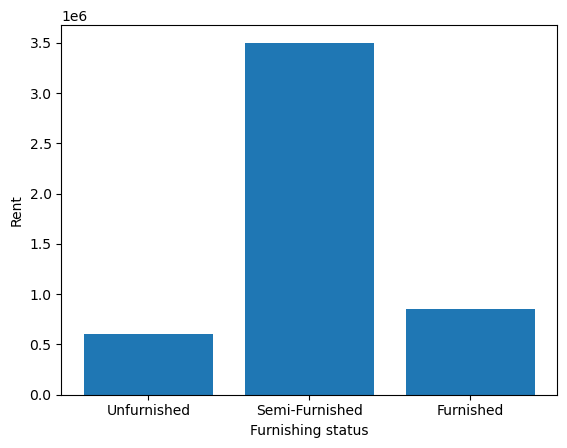

In [9]:
plt.bar(df["Furnishing Status"],df["Rent"])
plt.xlabel("Furnishing status")
plt.ylabel("Rent")

Here if we look at bar graph we can conclude,Semi furnished rents are more than unfurnished and furnished

Text(0, 0.5, 'Cities')

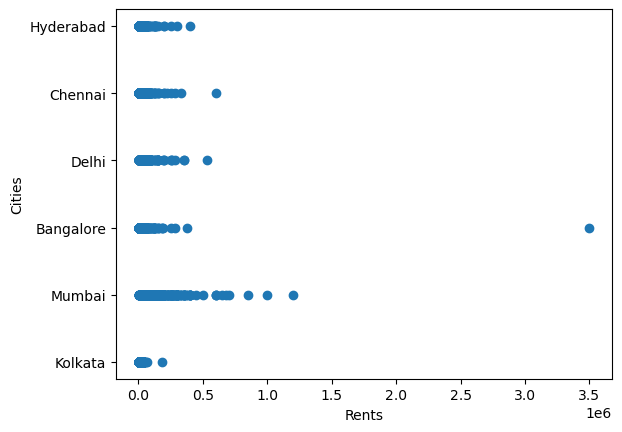

In [10]:
plt.scatter(df["Rent"],df["City"])
plt.xlabel("Rents")
plt.ylabel("Cities")

Text(0, 0.5, 'BHK')

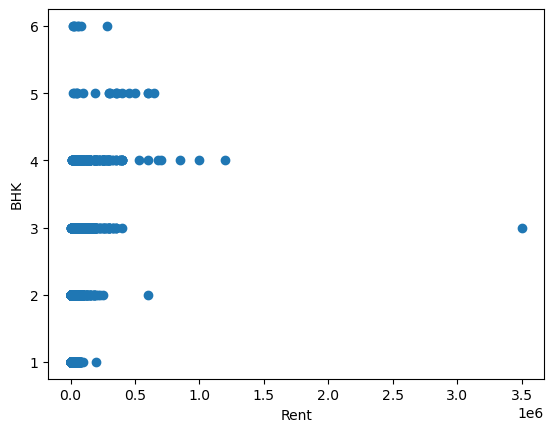

In [11]:
plt.scatter(df["Rent"],df["BHK"])
plt.xlabel("Rent")
plt.ylabel("BHK")

### Encoding Data

In [12]:
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [13]:
le = LabelEncoder()
df["Furnishing Status"] = le.fit_transform(df["Furnishing Status"])
df["Area Type"] = le.fit_transform(df["Area Type"])
df["Point of Contact"] = le.fit_transform(df["Point of Contact"])
df["City"] = le.fit_transform(df["City"])

In [14]:
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,2,4,2,Bachelors/Family,2,2
1,2,20000,800,2,4,1,Bachelors/Family,1,2
2,2,17000,1000,2,4,1,Bachelors/Family,1,2
3,2,10000,800,2,4,2,Bachelors/Family,1,2
4,2,7500,850,1,4,2,Bachelors,1,2


In [15]:
df["Tenant Preferred"] = df["Tenant Preferred"].replace({
    "Bachelors/Family":"Both"
})

df["Tenant Preferred"] = le.fit_transform(df["Tenant Preferred"])

### Removing outliers

In [16]:

num_cols = df.select_dtypes(include=['int64', 'float64'])
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

df = df[~((num_cols < (Q1 - 1.5 * IQR)) |
          (num_cols > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Final dataset shape:", df.shape)


Final dataset shape: (3055, 9)


### Performing heatmaps

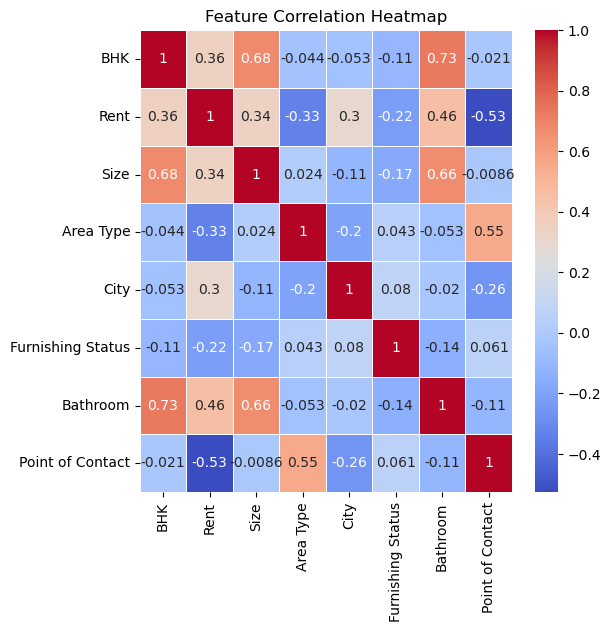

In [17]:
corr_matrix = df.drop("Tenant Preferred", axis=1).corr()


plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,2,4,2,1,2,2
1,2,20000,800,2,4,1,1,1,2
2,2,17000,1000,2,4,1,1,1,2
3,2,10000,800,2,4,2,1,1,2
5,2,7000,600,2,4,2,1,2,2


### Dividing data into training data and testing

In [19]:
X = df.drop(columns = "Rent")
y = df["Rent"]

In [20]:
X.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,2,4,2,1,2,2
1,2,800,2,4,1,1,1,2
2,2,1000,2,4,1,1,1,2
3,2,800,2,4,2,1,1,2
5,2,600,2,4,2,1,2,2


In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

### Scaling data

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training on different models

### Linear Regression

In [23]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)

y_pred = lr.predict(X_test_scaled)

lr_r2 = r2_score(y_test,y_pred)
lr_mse = mean_squared_error(y_test,y_pred)
lr_mae = mean_absolute_error(y_test,y_pred)

print("r2 score value",r2_score(y_test,y_pred))
print("mse = ", mean_squared_error(y_test,y_pred))
print("mae ",mean_absolute_error(y_test,y_pred))

r2 score value 0.4964348180090056
mse =  84569840.17176521
mae  6728.346766767557


### Support vector machine

In [24]:
svr = SVR(
    kernel = "linear",
    epsilon = 0.2
)
svr.fit(X_train_scaled,y_train)

y_pred = svr.predict(X_test_scaled)

svr_r2 = r2_score(y_test,y_pred)
svr_mse = mean_squared_error(y_test,y_pred)
svr_mae = mean_absolute_error(y_test,y_pred)

print("r2 score value",r2_score(y_test,y_pred))
print("mse = ", mean_squared_error(y_test,y_pred))
print("mae ",mean_absolute_error(y_test,y_pred))

r2 score value 0.10553691080579253
mse =  150218091.31762072
mae  7630.681001715143


### Decision Tree regressor

In [25]:
dtr = DecisionTreeRegressor(
    max_depth = 15,
    min_samples_leaf = 5,
    min_samples_split = 7,
    ccp_alpha = 0.1
)
dtr.fit(X_train_scaled,y_train)

y_pred = dtr.predict(X_test_scaled)

dtr_r2 = r2_score(y_test,y_pred)
dtr_mse = mean_squared_error(y_test,y_pred)
dtr_mae = mean_absolute_error(y_test,y_pred)

print("r2 score value",r2_score(y_test,y_pred))
print("mse = ", mean_squared_error(y_test,y_pred))
print("mae ",mean_absolute_error(y_test,y_pred))

r2 score value 0.7038624511384979
mse =  49733988.90895406
mae  4707.82832038924


### Random Forest regressor

In [26]:
rfr = RandomForestRegressor(
    n_estimators = 150,
    max_depth = 20,
    min_samples_leaf = 5,
    min_samples_split = 7,
    ccp_alpha = 0.1
)
rfr.fit(X_train_scaled,y_train)

y_pred = rfr.predict(X_test_scaled)

rfr_r2 = r2_score(y_test,y_pred)
rfr_mse = mean_squared_error(y_test,y_pred)
rfr_mae = mean_absolute_error(y_test,y_pred)

print("r2 score value",r2_score(y_test,y_pred))
print("mse = ", mean_squared_error(y_test,y_pred))
print("mae ",mean_absolute_error(y_test,y_pred))

r2 score value 0.7190700378007353
mse =  47179993.47912967
mae  4558.067372907228


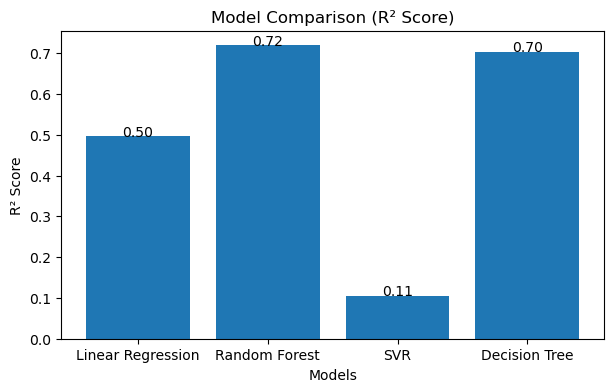

In [27]:
models = ['Linear Regression', 'Random Forest', 'SVR', 'Decision Tree']
r2_scores = [lr_r2, rfr_r2, svr_r2, dtr_r2]

plt.figure(figsize=(7,4))
plt.bar(models, r2_scores)

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

for i, v in enumerate(r2_scores):
    plt.text(i, v, f"{v:.2f}", ha='center')



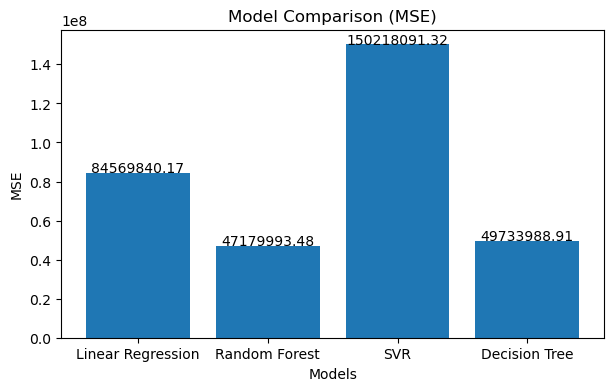

In [28]:

models = ['Linear Regression', 'Random Forest', 'SVR', 'Decision Tree']
mse_scores = [lr_mse, rfr_mse, svr_mse, dtr_mse]

plt.figure(figsize=(7,4))
plt.bar(models, mse_scores)

plt.title("Model Comparison (MSE)")
plt.xlabel("Models")
plt.ylabel("MSE")

for i, v in enumerate(mse_scores):
    plt.text(i, v, f"{v:.2f}", ha='center')


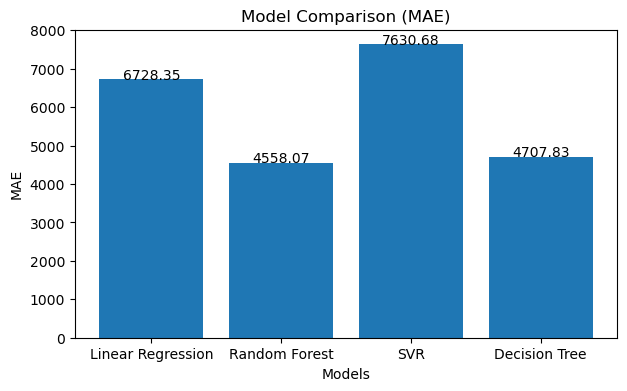

In [29]:
models = ['Linear Regression', 'Random Forest', 'SVR', 'Decision Tree']
mae_scores = [lr_mae, rfr_mae, svr_mae, dtr_mae]

plt.figure(figsize=(7,4))
plt.bar(models, mae_scores)

plt.title("Model Comparison (MAE)")
plt.xlabel("Models")
plt.ylabel("MAE")

for i, v in enumerate(mae_scores):
    plt.text(i, v, f"{v:.2f}", ha='center')


### Here we conclude Random forest comes out to be efficient to predict the rent on basis of given features